In [1]:
using Oceananigans
using CairoMakie
using CairoMakie.Colors
using Statistics

include("../src-fig/figures/preinitial_conditions.jl")
include("../src-simulation/parameters.jl")
include("../src-simulation/base_state.jl")
include("../src-simulation/grid_faces.jl")

include("../src-fig/plotting.jl")
include("front.jl")

[ Info: Oceananigans will use 4 threads


front_width (generic function with 1 method)

In [2]:
DFM = "../../scratch/turbulence-at-many-fronts/Strain-l8/DFM.jld2"
RI = "../../scratch/turbulence-at-many-fronts/Strain-l8/RI.jld2"
PV = "../../scratch/turbulence-at-many-fronts/Strain-l8/PV.jld2"
TKE = "../../scratch/turbulence-at-many-fronts/Strain-l8/TKE.jld2"

iterations, times = iterations_times(DFM)
sp = simulation_parameters(DFM)
xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
inds = center_indices(DFM)
grid = jldopen(get_grid, DFM)

1024×128×64 RectilinearGrid{Float64, Bounded, Periodic, Bounded} on CPU with 5×5×5 halo
├── Bounded  x ∈ [-16000.0, 16000.0] variably spaced with min(Δx)=5.20833, max(Δx)=315.273
├── Periodic y ∈ [-333.333, 333.333) regularly spaced with Δy=5.20833
└── Bounded  z ∈ [-150.0, 0.0]       regularly spaced with Δz=2.34375

# Time
Since we are starting with a variable initial widths, the width at which the strain turns on is different between simulations. To account for this, we use a strain-normalized time coordinate 
$$
s(t) = \int_{0}^t \alpha (t_1) \text{d}t_1.
$$
A passive tracer $c$ would then obey
$$
c(x, s) = c(xe^{s}, 0),
$$
regardless of details of the time-dependent strain rate $\alpha$.

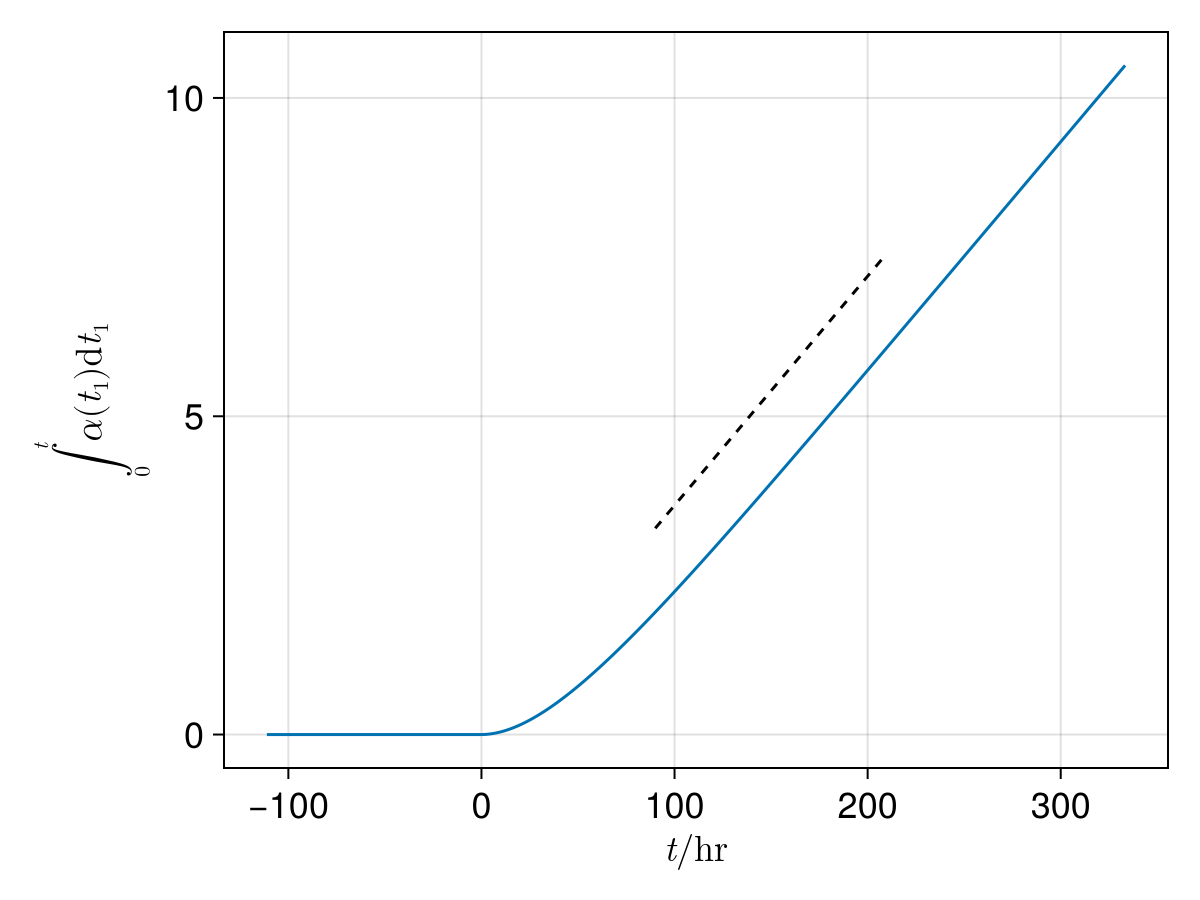

In [3]:
# Time coordinate is the cumulative deformation
∫αdt = normalized_time(DFM)
fig = Figure(; fontsize=18)
ax = Axis(fig[1, 1],
    xlabel = L"t / \text{hr}", 
    ylabel = L"\int_{0}^t\alpha(t_1) \text{d} t_1"
) 
lines!(ax, times ./ 3600, ∫αdt)
lines!(ax, range(90, 210, 100), sp.α .* range(90, 210, 100) .* 3600; color=:black, linestyle=:dash)
fig

# Mixed layer depth
The height of the mixed layer changes as the front evolves. The mixed layer height $\eta$ is defined as the height at which the buoyancy is $\Delta b / 6$ than the value at the surface above
$$
\overline{b}(x, \eta(x, t), t) = b_\text{surface}(x, t) - \Delta b / 6
$$
$b_\text{surface}$ is an average of $\overline{b}$ over $z \in [-10~\text{m}, -5~\text{m}]$

In [ ]:
db = -sp.Δb / 6
BT = cumulative_avg_b(DFM)

b_surface = avg_buoyancy(DFM, -10, -5)
b_center = avg_buoyancy(DFM, -0.95sp.H, -0.05sp.H)

η, η_k = mixed_layer_height(DFM, b_surface, db)
b_mixed = mld_buoyancy(DFM, η_k, -5);

In [87]:
DFM = "../../scratch/turbulence-at-many-fronts/Strain-l8/DFM.jld2"
function buoyancy_video(DFM, filename)
    n = Observable(201)
    fig = Figure(; size=(1500, 300), fontsize=18)
    
    ∫αdt = normalized_time(DFM)
    iterations, times = iterations_times(DFM)
    sp = simulation_parameters(DFM)
    xsᶜ, xsᶠ, ysᶜ, ysᶠ, zsᶜ, zsᶠ = grid_nodes(DFM)
    
    title = @lift let
        t_val = @sprintf "%03.1f" sp.f * times[$n] / 2π
        hr_val = @sprintf "%03.0f" times[$n] / 3600
        s_val = @sprintf "%03.2f" ∫αdt[$n]
        L"ft / 2\pi = %$(t_val) \quad s = %$(s_val) \quad t = %$(hr_val)~\text{hr} "
    end
    
    ax_x = Axis(fig[1, 1];
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lx / 2000, sp.Lx / 2000, -sp.Lz, 0),
        title
    )
    
    ax_h = Axis(fig[1, 2];
        xlabel = L"x / \text{km}",
        ylabel = L"z / \text{m}",
        limits = (-sp.Lh / 2000, sp.Lh / 2000, -sp.Lz, 0),
        title
    )
    hideydecorations!(ax_h; ticks=false)
    
    b = @lift (get_field(DFM, "b_dfm", iterations[$n]) .- mean(b_center[$n, :])) ./ sp.Δb
    mld = @lift η[$n, :]
    
    levels = (-0.5):(1 / 6):(0.5)
    colormap = reverse(to_colormap(:deep))
    
    bl = -1 / 3
    br = 1 / 3
    ctfs = map([ax_x, ax_h]) do ax
        ctf = contourf!(ax, xsᶜ ./ 1000, zsᶜ, b; 
            colormap,
            levels,
            extendlow=:white
        )
        contour!(ax, xsᶜ ./ 1000, zsᶜ, b; 
            color = :red,
            levels = [bl]
        )
        contour!(ax, xsᶜ ./ 1000, zsᶜ, b; 
            color = :red,
            levels = [br]
        )
    
        lines!(ax, xsᶜ ./ 1000, mld;
            color = :blue
        )
    
        lines!(ax, xsᶜ ./ 1000, x->-0.05sp.H;
            color = (:black, 0.3)
        )
        lines!(ax, xsᶜ ./ 1000, x->-0.95sp.H;
            color = (:black, 0.3)
        )
        ctf
    end
    
    subfig_label!(fig[1, 1], 1; fontsize=18)
    subfig_label!(fig[1, 2], 2; fontsize=18)
    Colorbar(fig[1, 3], ctfs[1]; label=L"b / \Delta b")
    N = length(iterations)
    
    println()
    record(fig, filename, 1:N; framerate=12) do i
        print("\r$i / $N")
        n[] = i
    end
    println()
    
    fig
end

buoyancy_video (generic function with 2 methods)


801 / 801

801 / 801

801 / 801

801 / 801


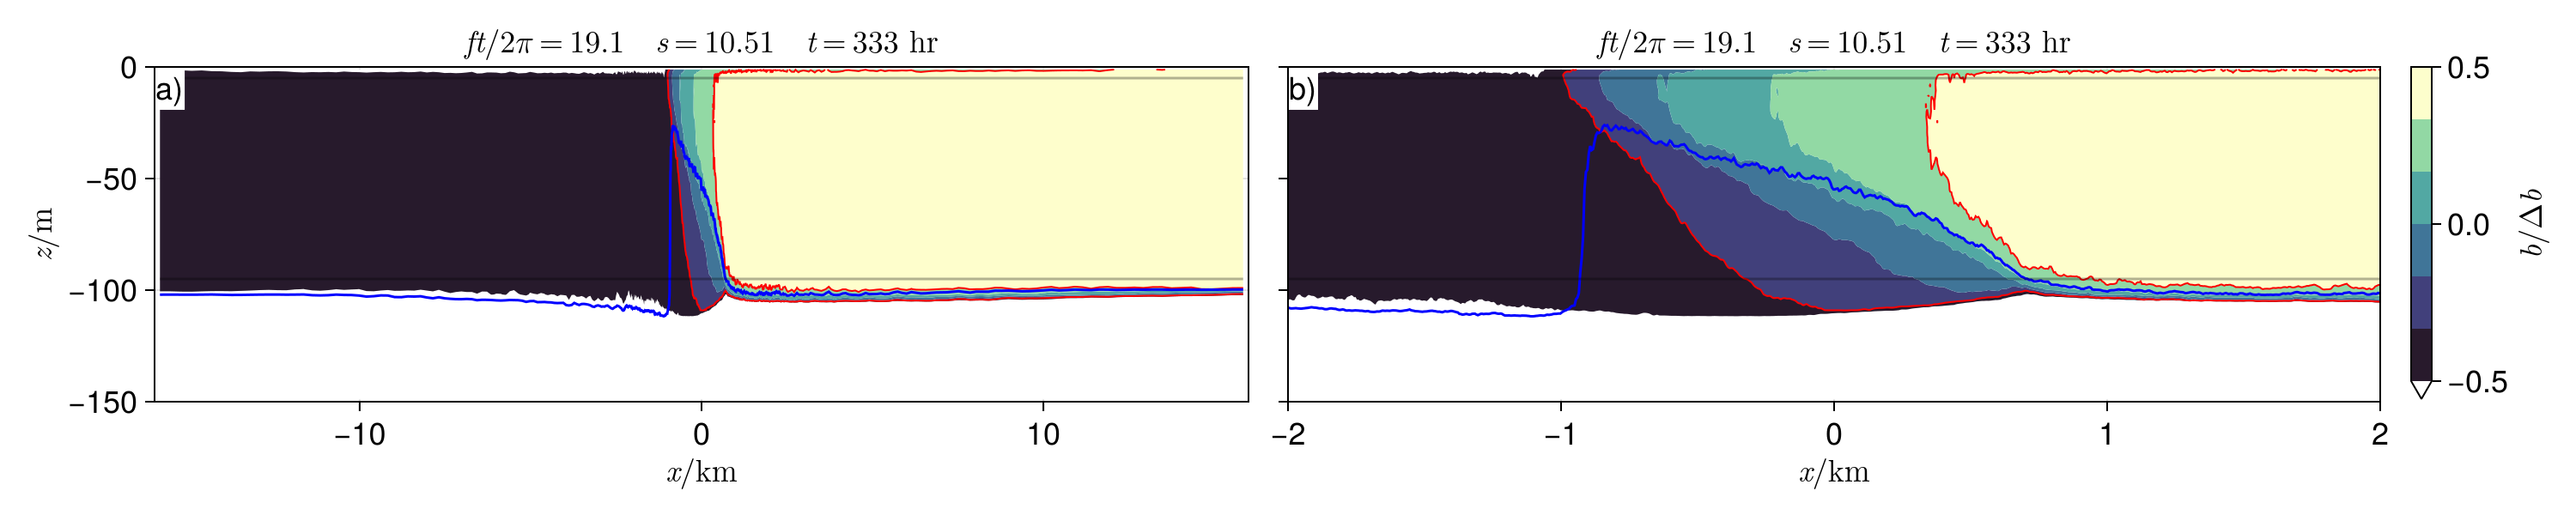

In [88]:
buoyancy_video("../../scratch/turbulence-at-many-fronts/Strain-l2/DFM.jld2", "buoyancy-l2.mp4")
buoyancy_video("../../scratch/turbulence-at-many-fronts/Strain-l4/DFM.jld2", "buoyancy-l4.mp4")
buoyancy_video("../../scratch/turbulence-at-many-fronts/Strain-l6/DFM.jld2", "buoyancy-l6.mp4")
buoyancy_video("../../scratch/turbulence-at-many-fronts/Strain-l8/DFM.jld2", "buoyancy-l6.mp4")

In [75]:
Ek = (sp.B / sp.H^2)^(1/3) / sp.f
sp.H^2 * (sp.f * 1)^3 / sp.B

0.21172227344203767

# Front definition
We have multiple possible ways to define the front. I am going to check a few. We have the surface buoyancy, as before,
$$
b_\text{surface}(x, t) = \frac{1}{0.05H}\int_{-0.1H}^{-0.05H} b(x, z, t) ~\text{d}z
$$
As well as
$$
b_\text{center}(x, t) = \frac{1}{0.6H}\int_{-0.95H}^{-0.05H} b(x, z, t) ~\text{d}z,
$$
and
$$
b_\text{mixed}(x, t) = \frac{1}{-0.05H-\eta(x, t)}\int_{\eta(x, t)}^{-0.05H} b(x, z, t) ~\text{d}z
$$.


Below is a plot comparing the various measures. Red contours are the buoyancy levels used to define the frontal width, 
$$
\frac{1}{L_x}\int_{-L_x / 2}^{L_x / 2} b_i(x, t)\,\text{d}x \pm \Delta b / 3
$$

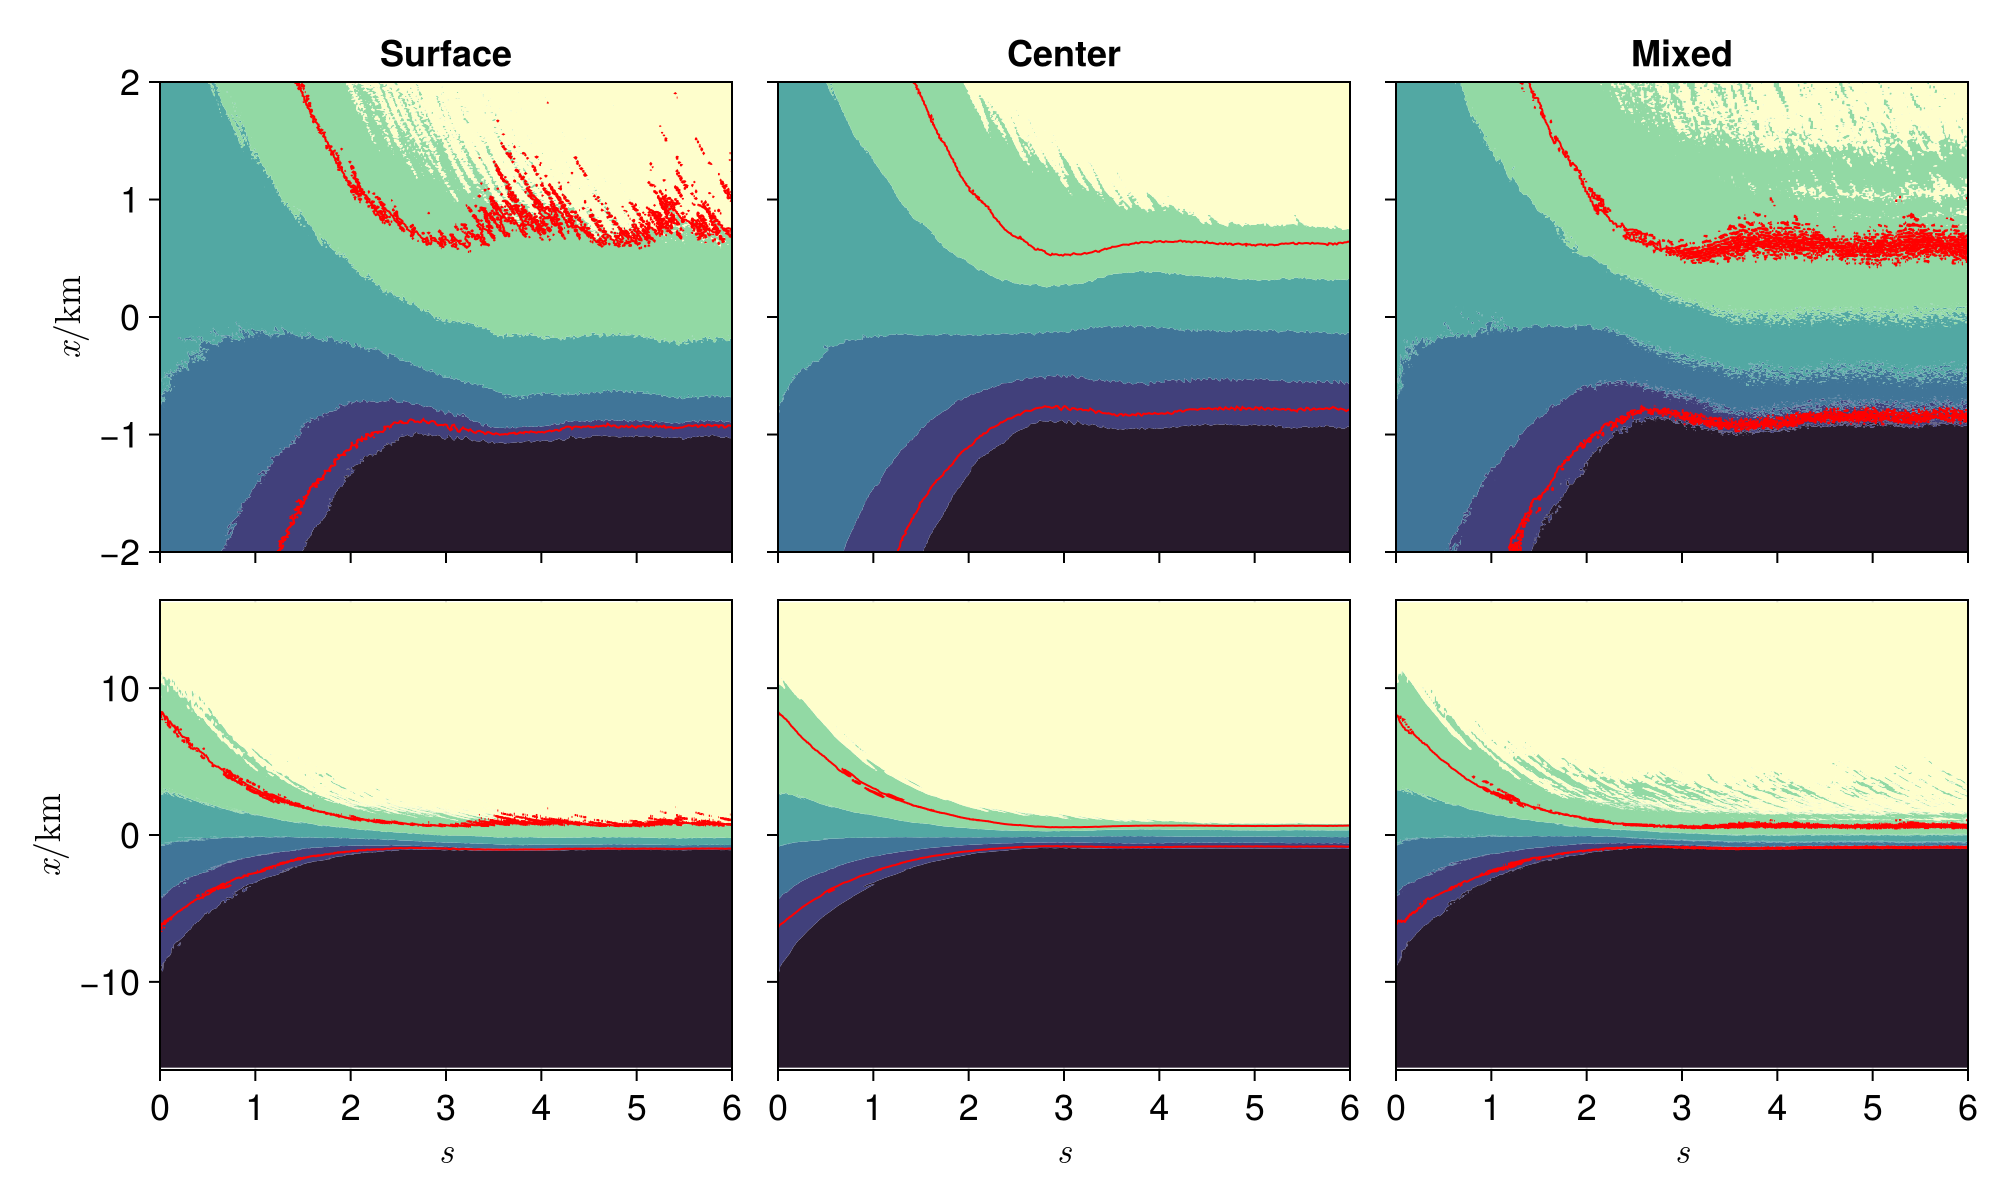

In [12]:
levels = (-sp.Δb / 5):(sp.Δb / 5):sp.Δb
colormap = reverse(to_colormap(:deep))

bl = -sp.Δb / 3
br = sp.Δb / 3

fig = Figure(; 
    fontsize = 18,
    size = (1000, 600)
)

ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"x / \text{km}",
    limits = (0, 6, -sp.Lh / 2000, sp.Lh / 2000),
    title = "Surface"
)

contourf!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- BT; levels, colormap)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- mean(b_surface; dims=2); levels = [bl], color = :red)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- mean(b_surface; dims=2); levels = [br], color = :red)
hidexdecorations!(ax; ticks = false)

ax = Axis(fig[1, 2];
    xlabel = L"s",
    ylabel = L"x / \text{km}",
    limits = (0, 6, -sp.Lh / 2000, sp.Lh / 2000),
    title = "Center"
)

contourf!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- BT; levels, colormap)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- mean(b_center; dims=2); levels = [bl], color = :red)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- mean(b_center; dims=2); levels = [br], color = :red)
hidexdecorations!(ax; ticks = false)
hideydecorations!(ax; ticks = false)

ax = Axis(fig[1, 3];
    xlabel = L"s",
    ylabel = L"x / \text{km}",
    limits = (0, 6, -sp.Lh / 2000, sp.Lh / 2000),
    title = "Mixed"
)

contourf!(ax, ∫αdt, xsᶜ ./ 1000, b_mixed .- BT; levels, colormap)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_mixed .- mean(b_mixed; dims=2); levels = [bl], color = :red)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_mixed .- mean(b_mixed; dims=2); levels = [br], color = :red)
hidexdecorations!(ax; ticks = false)
hideydecorations!(ax; ticks = false)

ax = Axis(fig[2, 1];
    xlabel = L"s",
    ylabel = L"x / \text{km}",
    limits = (0, 6, -sp.Lx / 2000, sp.Lx / 2000),
)

contourf!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- BT; levels, colormap)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- mean(b_surface; dims=2); levels = [bl], color = :red)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_surface .- mean(b_surface; dims=2); levels = [br], color = :red)

ax = Axis(fig[2, 2];
    xlabel = L"s",
    ylabel = L"x / \text{km}",
    limits = (0, 6, -sp.Lx / 2000, sp.Lx / 2000),
)

contourf!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- BT; levels, colormap)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- mean(b_center; dims=2); levels = [bl], color = :red)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_center .- mean(b_center; dims=2); levels = [br], color = :red)
hideydecorations!(ax; ticks = false)

ax = Axis(fig[2, 3];
    xlabel = L"s",
    ylabel = L"x / \text{km}",
    limits = (0, 6, -sp.Lx / 2000, sp.Lx / 2000),
)

contourf!(ax, ∫αdt, xsᶜ ./ 1000, b_mixed .- BT; levels, colormap)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_mixed .- mean(b_mixed; dims=2); levels = [bl], color = :red)
contour!(ax, ∫αdt, xsᶜ ./ 1000, b_mixed .- mean(b_mixed; dims=2); levels = [br], color = :red)
hideydecorations!(ax; ticks = false)

fig

In [13]:
bl = -sp.Δb / 3
br = sp.Δb / 3

ilr_surface, xlr_surface, ℓ_surface = front_width(DFM, b_surface .- mean(b_surface; dims=2), bl, br)
ilr_center, xlr_center, ℓ_center = front_width(DFM, b_center .- mean(b_center; dims=2), bl, br)
ilr_mixed, xlr_mixed, ℓ_mixed = front_width(DFM, b_mixed .- mean(b_mixed; dims=2), bl, br);

The following plot is the various measures of the frontal width $\ell$ over time. Length scales which evolve passively with the background flow have gradient equal to the black, dashed line. The red, dash-dot line is the deformation radius of the reference front used to define the initial conditions.

The evolution follows the passive strain flow evolution initially, but is arrested at the deformation radius.

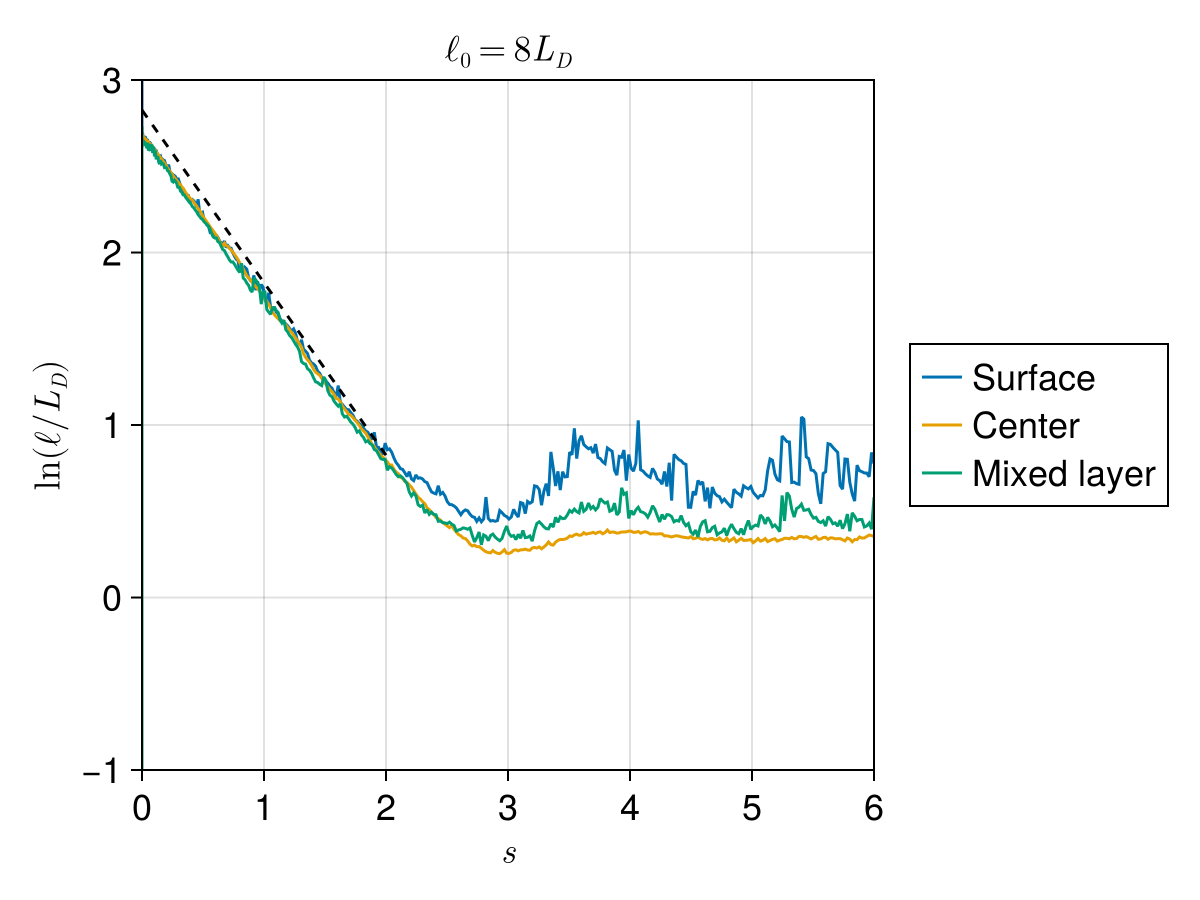

In [16]:
fig = Figure(; fontsize=18)
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\ln(\ell / L_D)",
    limits = (0, 6, -1, 3),
    title = L"\ell_0 = 8L_D"
)
ln_surface = lines!(ax, ∫αdt, log.(ℓ_surface ./ sp.L))
ln_center = lines!(ax, ∫αdt, log.(ℓ_center ./ sp.L))
ln_mixed = lines!(ax, ∫αdt, log.(ℓ_mixed ./ sp.L))
ln_ref = lines!(ax, range(0, 2, 20), log.(ℓ_mixed[1] ./ sp.L) .- range(0, 2, 20); color=:black, linestyle=:dash)
#lines!(ax, range(0.1, 2.1, 20), t->log.(1); color = :red, linestyle = :dashdot)

Legend(fig[1, 2], [ln_surface, ln_center, ln_mixed], ["Surface", "Center", "Mixed layer"])
save("width-evolution-8L.png", fig; px_per_unit=2)
save("width-evolution-8L.svg", fig)
fig

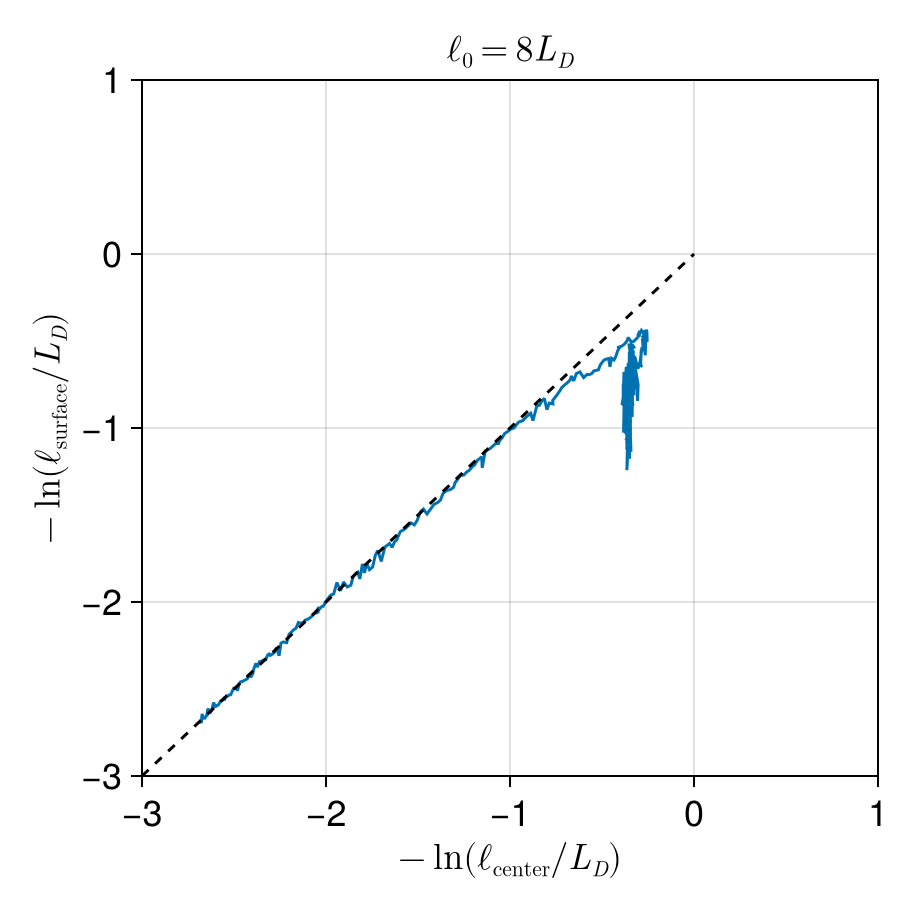

In [28]:
fig = Figure(; size=(455, 455), fontsize=18)
ax = Axis(fig[1, 1];
    xlabel = L"-\ln(\ell_\text{center} / L_D)",
    ylabel = L"-\ln(\ell_\text{surface} / L_D)",
    limits = (-3, 1, -3, 1),
    title = L"\ell_0 = 8L_D"
)
ln_surface = lines!(ax, -log.(ℓ_center[201:end] ./ sp.L), -log.(ℓ_surface[201:end] ./ sp.L))
ln_surface = lines!(ax, [-3, 0], [-3, 0]; color=:black, linestyle=:dash)

save("center-surface-8L.png", fig; px_per_unit=2)
save("center-surface-8L.svg", fig)
fig

# Frontogenesis: comparisons between simulations

Average square buoyancy gradient with different levels of coarse-graining?
$$
\langle b_{,x}\rangle^2, \langle b_{,z}\rangle^2
$$

In [169]:
foldernames = [
    "../../scratch/turbulence-at-many-fronts/Strain-l2",
    "../../scratch/turbulence-at-many-fronts/Strain-l4",
    "../../scratch/turbulence-at-many-fronts/Strain-l6",
    "../../scratch/turbulence-at-many-fronts/Strain-l8",
]
DFMs = map(foldernames) do foldername 
    joinpath(foldername, "DFM.jld2")
end
RIs = map(foldernames) do foldername 
    joinpath(foldername, "RI.jld2")
end
PVs = map(foldernames) do foldername 
    joinpath(foldername, "PV.jld2")
end
TKEs = map(foldernames) do foldername 
    joinpath(foldername, "TKE.jld2")
end

bx²s = map(RIs) do RI
    inds = center_indices(RI)
    iterations, times = iterations_times(RI)
    timeseries_of(RI, "M²", iterations) do field
        mean(filt(field[inds, 23:end-2], 3, 0) .^ 2)
    end
end

bx²s_surface = map(RIs) do RI
    inds = center_indices(RI)
    iterations, times = iterations_times(RI)
    timeseries_of(RI, "M²", iterations) do field
        mean(filt(field[inds, end-4:end-2], 3, 0) .^ 2)
    end
end

bzs = map(RIs) do RI
    inds = center_indices(RI)
    iterations, times = iterations_times(RI)
    timeseries_of(RI, "N²", iterations) do field
        mean(filt(field[inds, 23:end-2], 3, 0))
    end
end

Vqs = map(PVs) do PV
    inds = center_indices(PV)
    iterations, times = iterations_times(PV)
    timeseries_of(PV, "Vq_dfm", iterations) do field
        mean(filt(field[inds, 23:end-2], 3, 0))
    end
end

qs = map(PVs) do PV
    inds = center_indices(PV)
    iterations, times = iterations_times(PV)
    timeseries_of(PV, "q_dfm", iterations) do field
        mean(filt(field[inds, 23:end-2], 3, 0))
    end
end

VSPs = map(TKEs) do TKE
    inds = center_indices(TKE)
    iterations, times = iterations_times(TKE)
    timeseries_of(TKE, "VSP", iterations) do field
        mean(filt(field[inds, 23:end-2], 3, 0))
    end
end

BFLUXs = map(TKEs) do TKE
    inds = center_indices(TKE)
    iterations, times = iterations_times(TKE)
    timeseries_of(TKE, "BFLUX", iterations) do field
        mean(filt(field[inds, 23:end-2], 3, 0))
    end
end

ℓs = map(DFMs) do DFM
    BT = cumulative_avg_b(DFM)
    b_surface = avg_buoyancy(DFM, -10, -5)
    ilr_surface, xlr_surface, ℓ_surface = front_width(DFM, b_surface .- BT, bl, br)
    ℓ_surface
end;

In [188]:
Vqs = map(PVs) do PV
    inds = center_indices(PV)
    iterations, times = iterations_times(PV)
    timeseries_of(PV, "Vq_dfm", iterations) do field
        mean(field[inds, 23:end-2])
    end
end

qs = map(PVs) do PV
    inds = center_indices(PV)
    iterations, times = iterations_times(PV)
    timeseries_of(PV, "q_dfm", iterations) do field
        mean(field[inds, 23:end-2])
    end
end

VSPs = map(TKEs) do TKE
    inds = center_indices(TKE)
    iterations, times = iterations_times(TKE)
    timeseries_of(TKE, "VSP", iterations) do field
        mean(field[inds, 23:end-2])
    end
end

BFLUXs = map(TKEs) do TKE
    inds = center_indices(TKE)
    iterations, times = iterations_times(TKE)
    timeseries_of(TKE, "BFLUX", iterations) do field
        mean(field[inds, 23:end-2])
    end
end

4-element Vector{Vector{Float64}}:
 [7.418731537903903e-37, 5.1144866757682815e-27, 9.683542688830944e-27, 1.3214304925351806e-26, 1.384138469606735e-26, 5.140775494045726e-26, -2.6886477584444382e-25, -7.306787972751923e-25, 1.3087075879845807e-24, 1.5372191690037492e-23  …  1.2175381416475926e-8, 1.1972104921107775e-8, 1.227183294623899e-8, 1.2488915020921202e-8, 1.2524639919843638e-8, 1.220372004976361e-8, 1.2770695070926136e-8, 1.2870472672512513e-8, 1.3006677295833873e-8, 1.2647586855044257e-8]
 [1.4575608690606129e-36, 1.8462979312925333e-27, 3.5506537211917055e-27, 5.044047618512238e-27, 7.676028339064571e-27, 9.239973274170514e-27, -1.513305830679035e-26, -3.4803346273379566e-25, -2.960659876901045e-26, -2.5320860926471294e-24  …  1.2565129420183338e-8, 1.2824349973540845e-8, 1.2817887973658172e-8, 1.2588919125520042e-8, 1.2335545797427395e-8, 1.2265293600778056e-8, 1.2464781546900963e-8, 1.2833019764674275e-8, 1.2513477486399719e-8, 1.285120284621587e-8]
 [2.6713690155519724e-

In [150]:
# Passive tracer
bx²s_passive = map(DFMs) do DFM
    sp = simulation_parameters(DFM)
    map(∫αdt) do s
        mean([front_M²(x * exp(s), z, sp)^2 * exp(2 * s) for x in xsᶠ[inds], z in zsᶜ[22:end-2]])
    end
end

bx²s_surface_passive = map(DFMs) do DFM
    sp = simulation_parameters(DFM)
    map(∫αdt) do s
        mean([front_M²(x * exp(s), z, sp)^2 * exp(2 * s) for x in xsᶠ[inds], z in zsᶜ[end-4:end-2]])
    end
end
#=
ℓs_passive = map(DFMs) do DFM
    bl = sp.Δb / 5
    br = 3sp.Δb / 5
    b_surface = [front_buoyancy(x * exp(s), 0, sp) for s in ∫αdt, x in xsᶜ[inds]]
    ilr_surface, xlr_surface, ℓ_surface = front_width(DFM, b_surface, bl, br)
    ℓ_surface
end;
=#

4-element Vector{Vector{Float64}}:
 [1.4140837980427124e-15, 1.4140837980427124e-15, 1.4140837980427124e-15, 1.4140837980427124e-15, 1.4140837980427124e-15, 1.4140837980427124e-15, 1.4140837980427124e-15, 1.4140837980427124e-15, 1.4140837980427124e-15, 1.4140837980427124e-15  …  2.174803942024743e-9, 2.26352558233272e-9, 2.3558671087338783e-9, 2.4519762269220274e-9, 2.5520066699083364e-9, 2.656118443982798e-9, 2.7644780847131495e-9, 2.877258923390709e-9, 2.9946413643496012e-9, 3.1168131736031375e-9]
 [4.252011874188541e-16, 4.252011874188541e-16, 4.252011874188541e-16, 4.252011874188541e-16, 4.252011874188541e-16, 4.252011874188541e-16, 4.252011874188541e-16, 4.252011874188541e-16, 4.252011874188541e-16, 4.252011874188541e-16  …  5.437009855061858e-10, 5.6588139558318e-10, 5.889667771834696e-10, 6.129940567305069e-10, 6.380016674770841e-10, 6.640296109956995e-10, 6.911195211782874e-10, 7.193147308476773e-10, 7.486603410874003e-10, 7.792032934007844e-10]
 [1.9432759857289127e-16, 1.9432

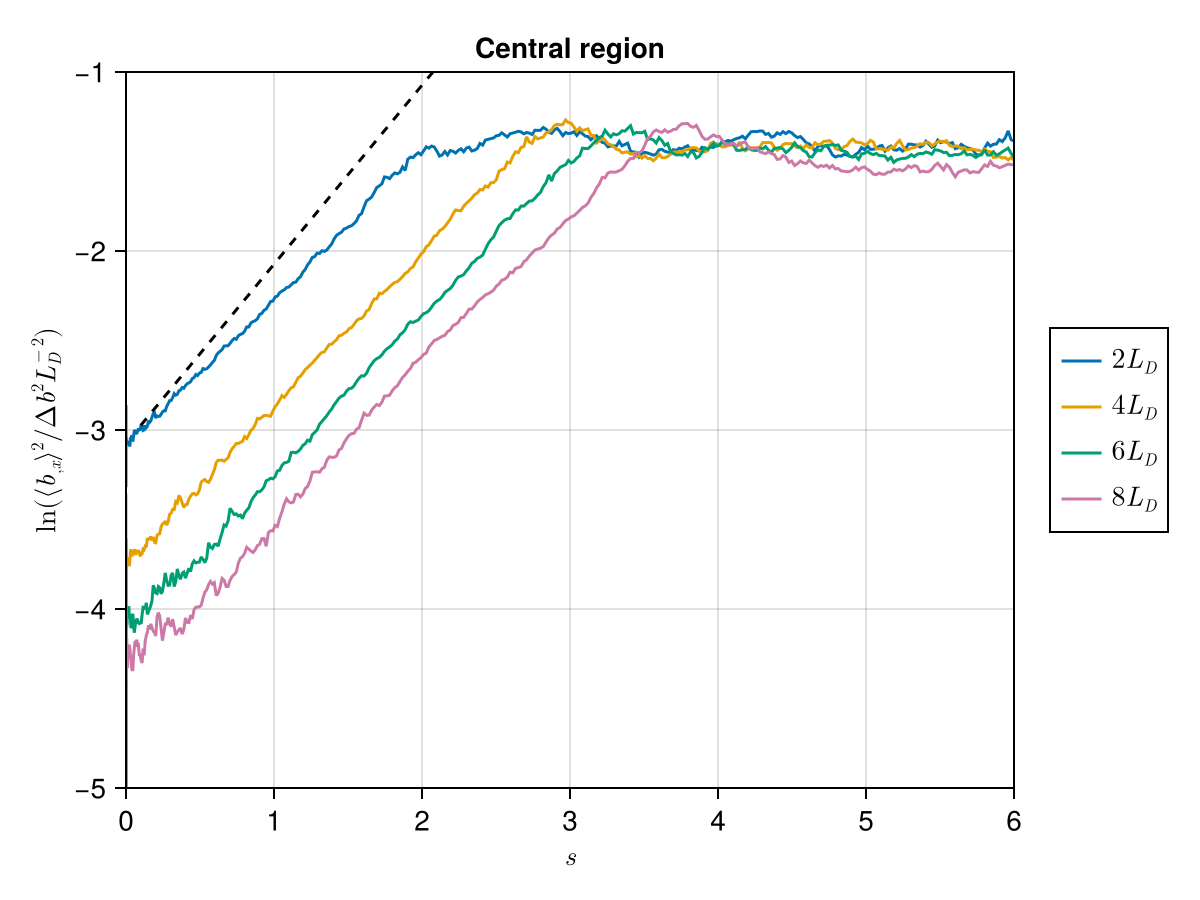

In [167]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\ln(\langle b_{,x}\rangle^2 / \Delta b^2 L_D^{-2})",
    limits = (0, 6, -5, -1),
    title = "Central region"
)

lns = map(bx²s) do bx²
    lines!(ax, ∫αdt, log.(sp.L^2 * bx² / sp.Δb^2))
end

lines!(ax, range(0.1, 2.1, 20), log.(sp.L^2 * bx²s[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)
#lines!(ax, ∫αdt, 0.2 .+ log.(sp.L^2 * bx²s_passive[1] / sp.Δb^2))

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

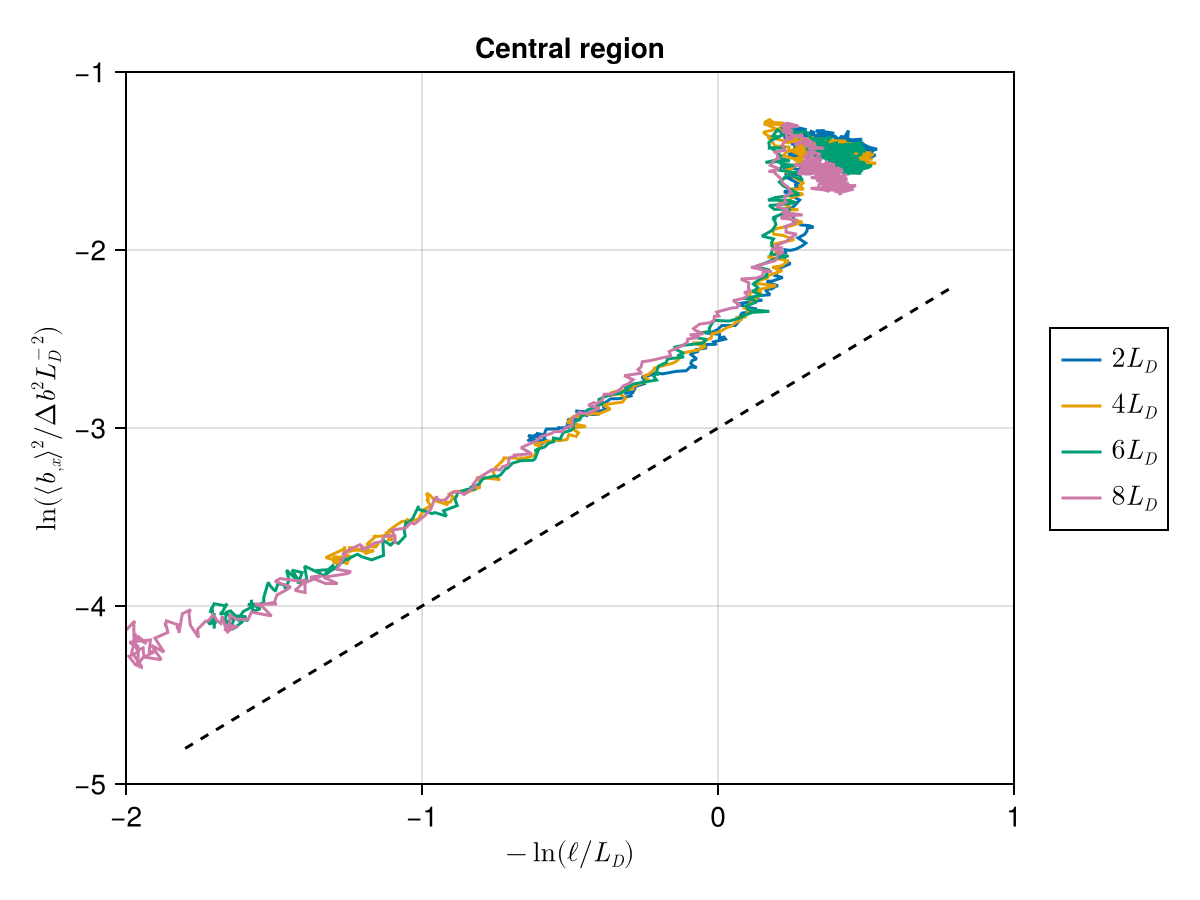

In [139]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"-\ln(\ell / L_D)",
    ylabel = L"\ln(\langle b_{,x}\rangle^2 / \Delta b^2 L_D^{-2})",
    limits = (-2, 1, -5, -1),
    title = "Central region"
)

lns = map(ℓs, bx²s) do ℓ, bx²
    lines!(ax, -log.(ℓ[201:end] ./ sp.L), log.(sp.L^2 * bx²[201:end] / sp.Δb^2))
end

lines!(ax, range(-1.8, 0.8, 100), ℓ->ℓ-3; color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

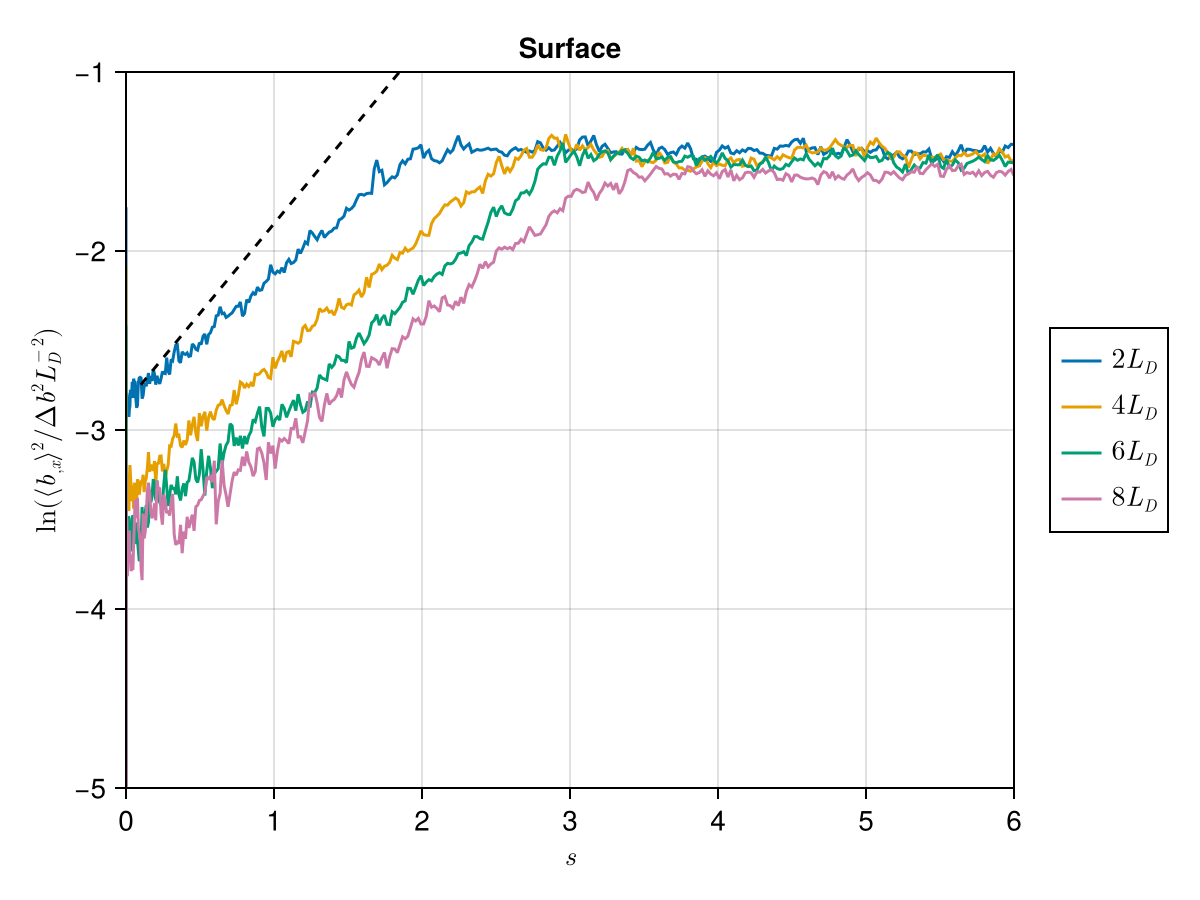

In [166]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\ln(\langle b_{,x}\rangle^2 / \Delta b^2 L_D^{-2})",
    limits = (0, 6, -5, -1),
    title = "Surface"
)

lns = map(bx²s_surface) do bx²
    lines!(ax, ∫αdt, log.(sp.L^2 * bx² / sp.Δb^2))
end
#lines!(ax, ∫αdt, 0.2 .+ log.(sp.L^2 * bx²s_surface_passive[3] / sp.Δb^2); color=:black, linestyle=:dash)
lines!(ax, range(0.1, 2.1, 20), log.(sp.L^2 * bx²s_surface[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

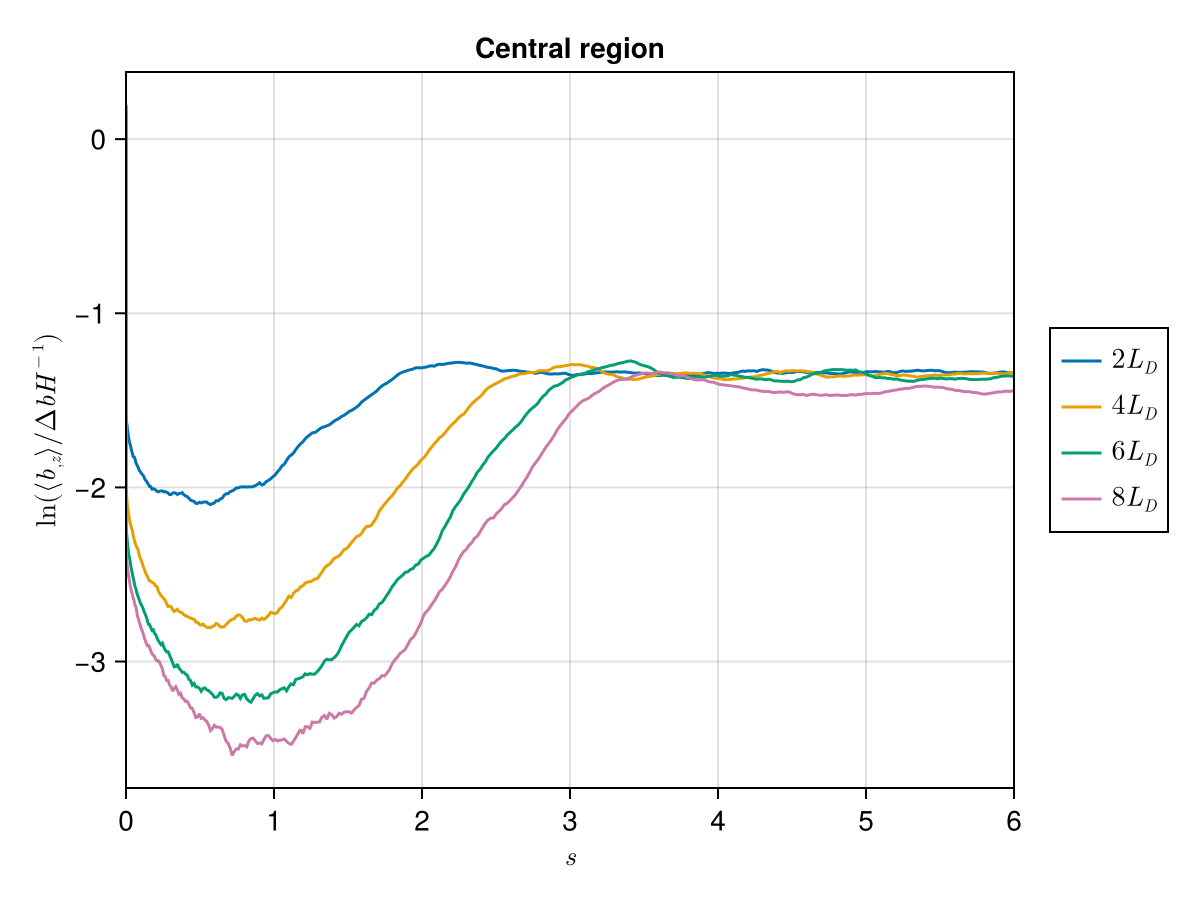

In [174]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\ln(\langle b_{,z}\rangle / \Delta b H^{-1})",
    limits = (0, 6, nothing, nothing),
    title = "Central region"
)

lns = map(bzs) do bz
    lines!(ax, ∫αdt, log.(sp.H * bz / sp.Δb))
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

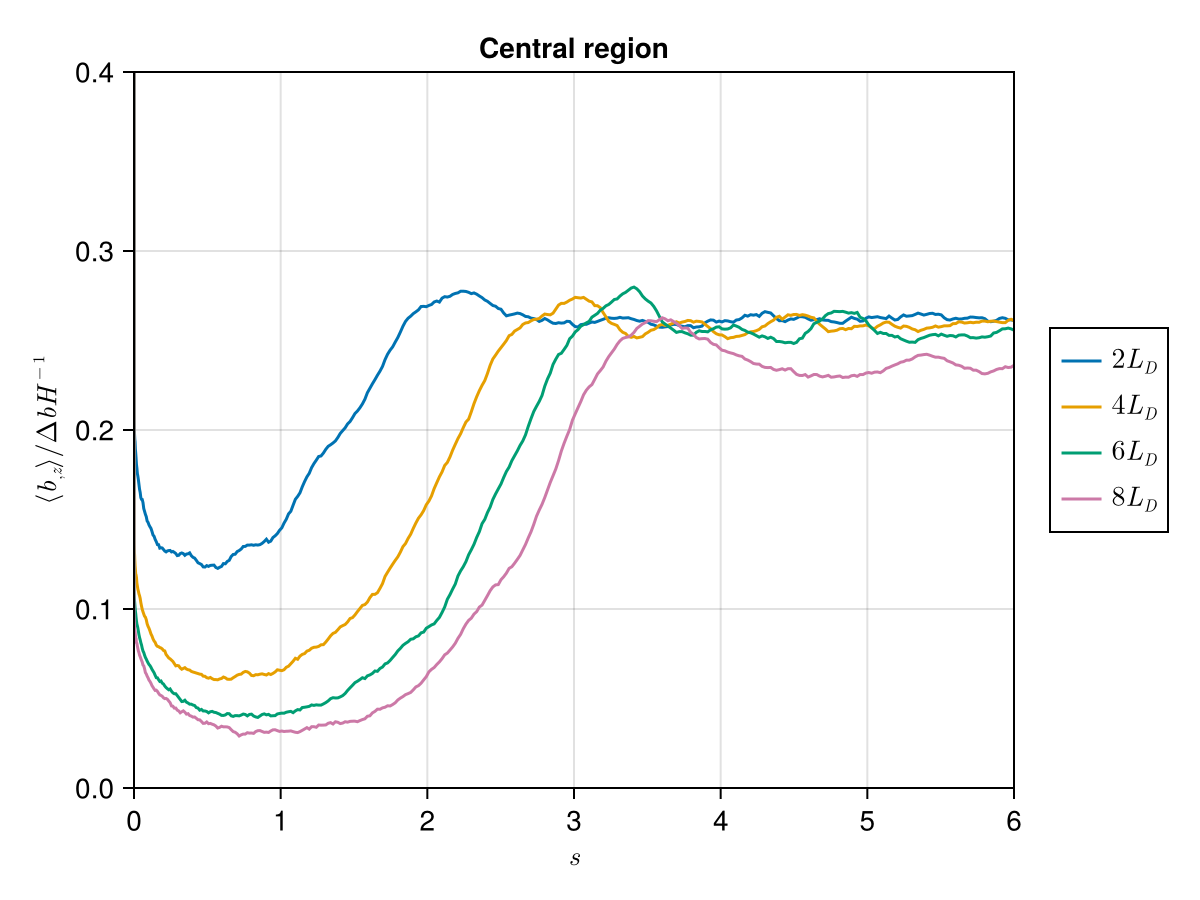

In [217]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\langle b_{,z}\rangle / \Delta b H^{-1}",
    limits = (0, 6, 0, 0.4),
    title = "Central region"
)

lns = map(bzs) do bz
    lines!(ax, ∫αdt, sp.H * bz / sp.Δb)
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

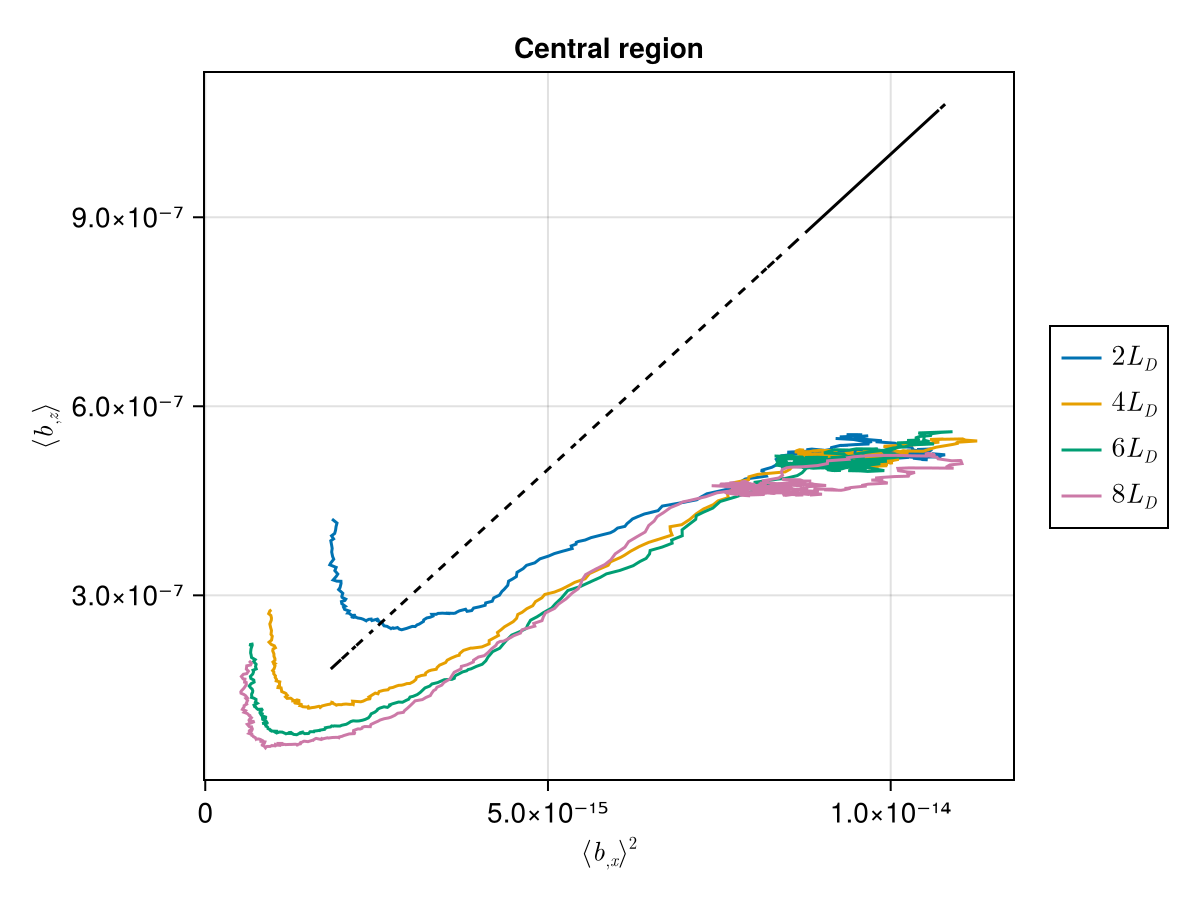

In [178]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"\langle b_{,x}\rangle^2",
    ylabel = L"\langle b_{,z}\rangle",
    limits = (nothing, nothing, nothing, nothing),
    title = "Central region"
)

lns = map(bx²s, bzs) do bx², bz
    lines!(ax, bx²[201:end], bz[201:end])
end
lines!(ax, bx²s[1][201:end], bx²->bx² / sp.f^2; color=:black, linestyle=:dash)
Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

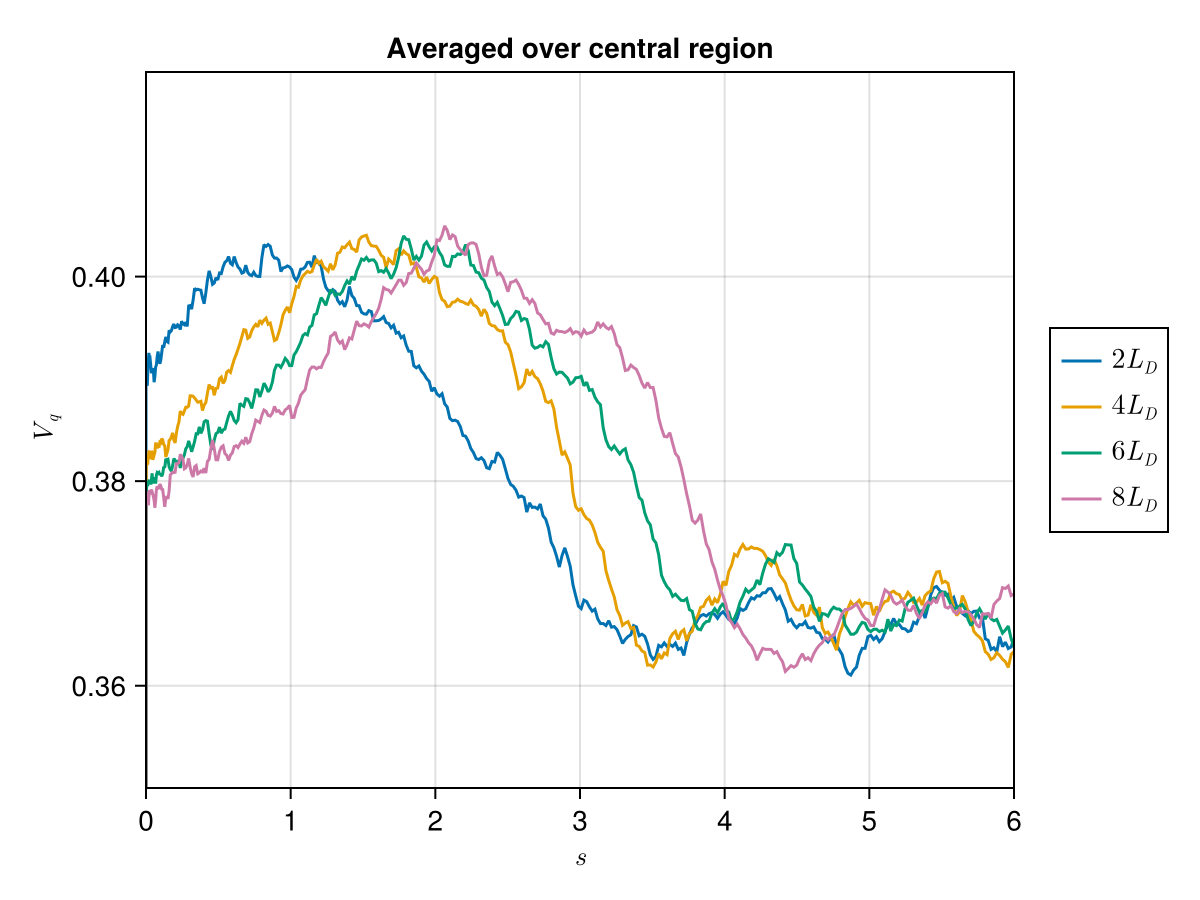

In [195]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"V_q",
    limits = (0, 6, 0.35, 0.42),
    title = "Averaged over central region"
)

lns = map(Vqs) do Vq
    lines!(ax, ∫αdt, Vq)
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

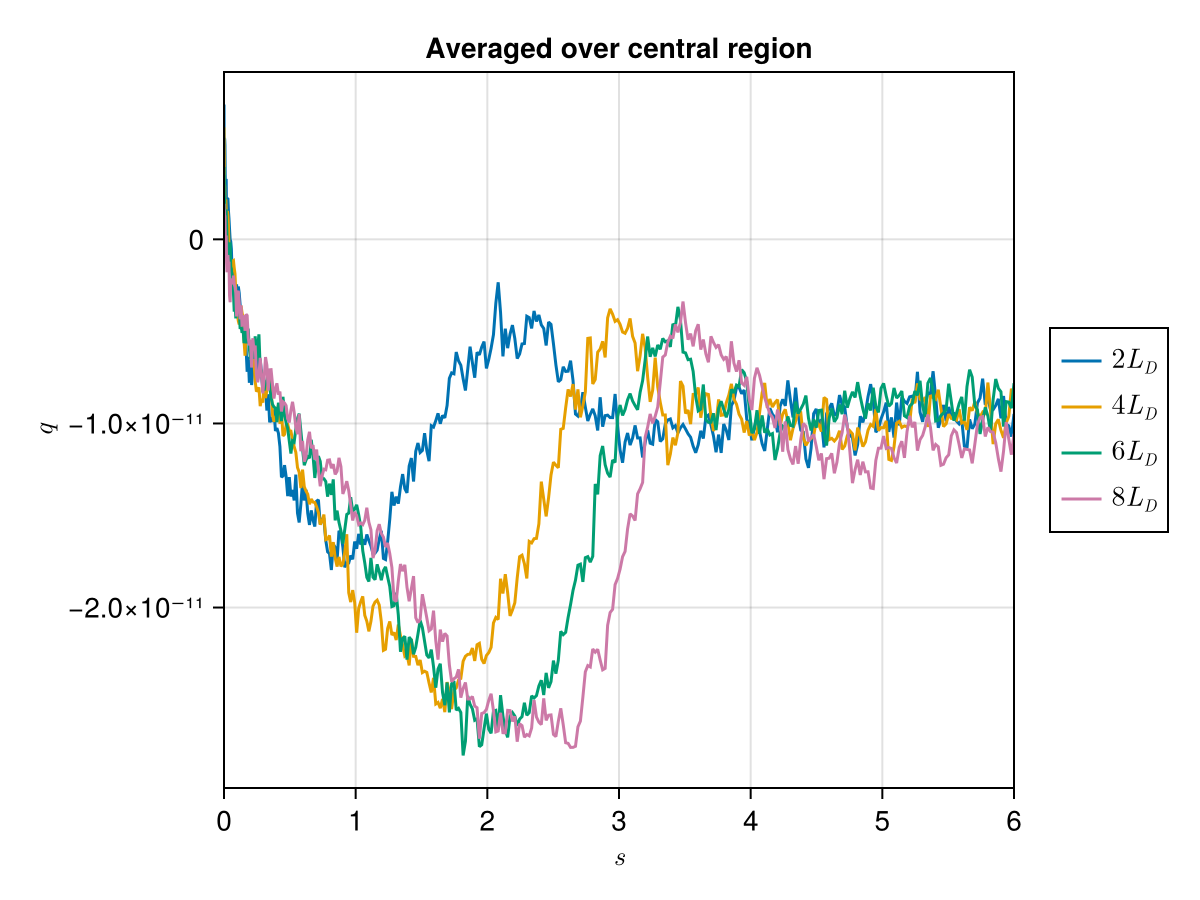

In [197]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"q",
    limits = (0, 6, nothing, nothing),
    title = "Averaged over central region"
)

lns = map(qs) do q
    lines!(ax, ∫αdt[201:end], q[201:end])
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

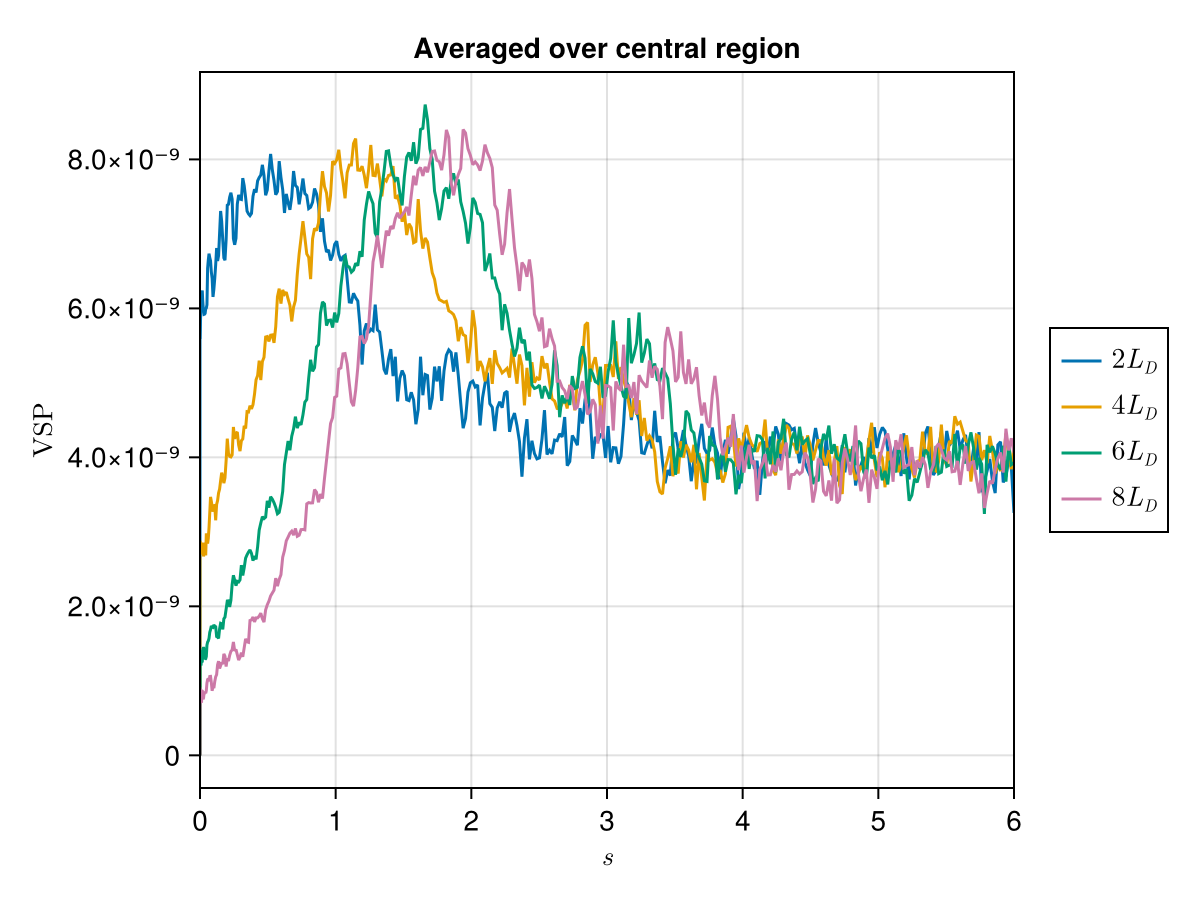

In [203]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"s",
    ylabel = L"\text{VSP}",
    limits = (0, 6, nothing, nothing),
    title = "Averaged over central region"
)

lns = map(VSPs) do VSP
    lines!(ax, ∫αdt, VSP)
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

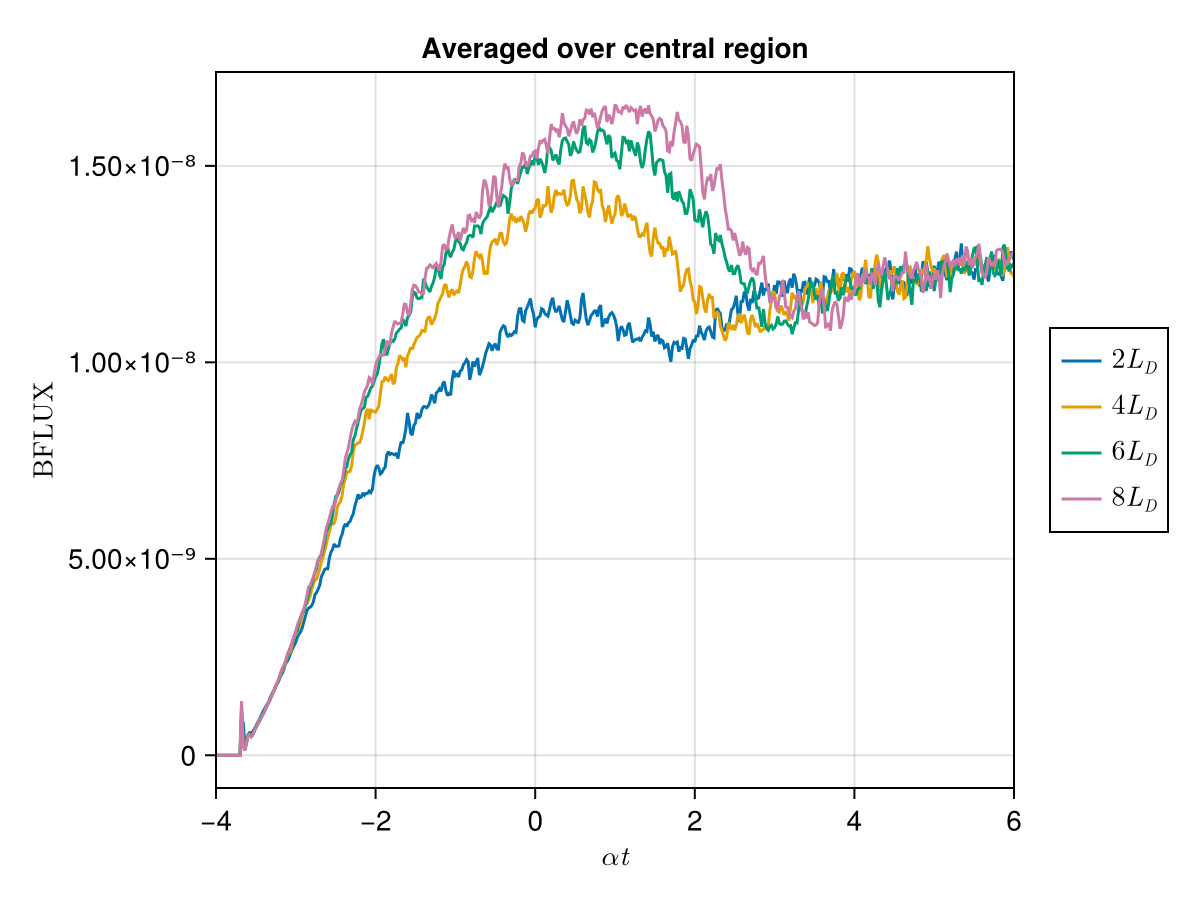

In [212]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"\alpha t",
    ylabel = L"\text{BFLUX}",
    limits = (-4, 6, nothing, nothing),
    title = "Averaged over central region"
)

lns = map(BFLUXs) do BFLUX
    lines!(ax, times .* sp.α, BFLUX)
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig

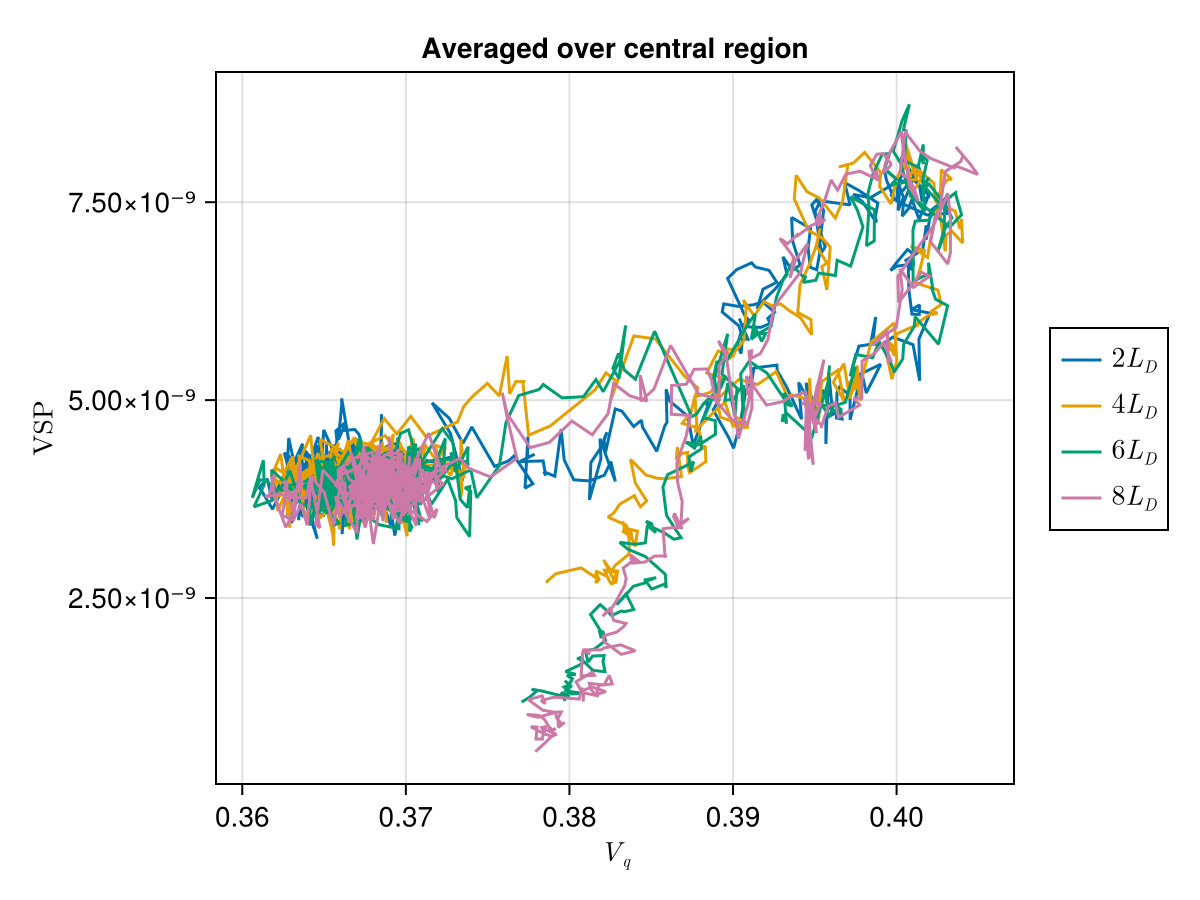

In [216]:
fig = Figure()
ax = Axis(fig[1, 1];
    xlabel = L"V_q",
    ylabel = L"\text{VSP}",
    limits = (nothing, nothing, nothing, nothing),
    title = "Averaged over central region"
)

lns = map(Vqs, VSPs) do Vq, VSP
    lines!(ax, Vq[201:end], VSP[201:end])
end

#lines!(ax, range(0.1, 2.1, 20), log.(sp.H^2 * bzs[1][201] / sp.Δb^2) .+ range(0.1, 2.1, 20); color=:black, linestyle=:dash)

Legend(fig[1, 2], lns, [L"2L_D", L"4L_D", L"6L_D", L"8L_D"], label=L"\ell_0")

fig